In [1]:
!pip install ultralytics==8.2.103 -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.1/875.1 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 111.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [6]:
import ultralytics
ultralytics.checks()


Ultralytics YOLOv8.2.103 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 42.0/112.6 GB disk)


In [11]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="na3kztUanfY3uHtBBIBA")
project = rf.workspace("dip-abbd6").project("traditional-boats-of-bangladesh")
version = project.version(15)
dataset = version.download("yolov8")




loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Traditional-boats-of-Bangladesh-15 in yolov8:: 100%|██████████| 4014/4014 [00:05<00:00, 786.65it/s]


In [10]:
#!rm -rf /content/Traditional-boats-of-Bangladesh-15



In [12]:
print(dataset.location)


/content/Traditional-boats-of-Bangladesh-15


In [13]:
!yolo task=detect mode=train model=yolov8s.pt data={dataset.location}/data.yaml epochs=80 imgsz=800 plots=True



New https://pypi.org/project/ultralytics/8.3.159 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.103 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/content/Traditional-boats-of-Bangladesh-15/data.yaml, epochs=80, time=None, patience=100, batch=16, imgsz=800, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train3, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, e

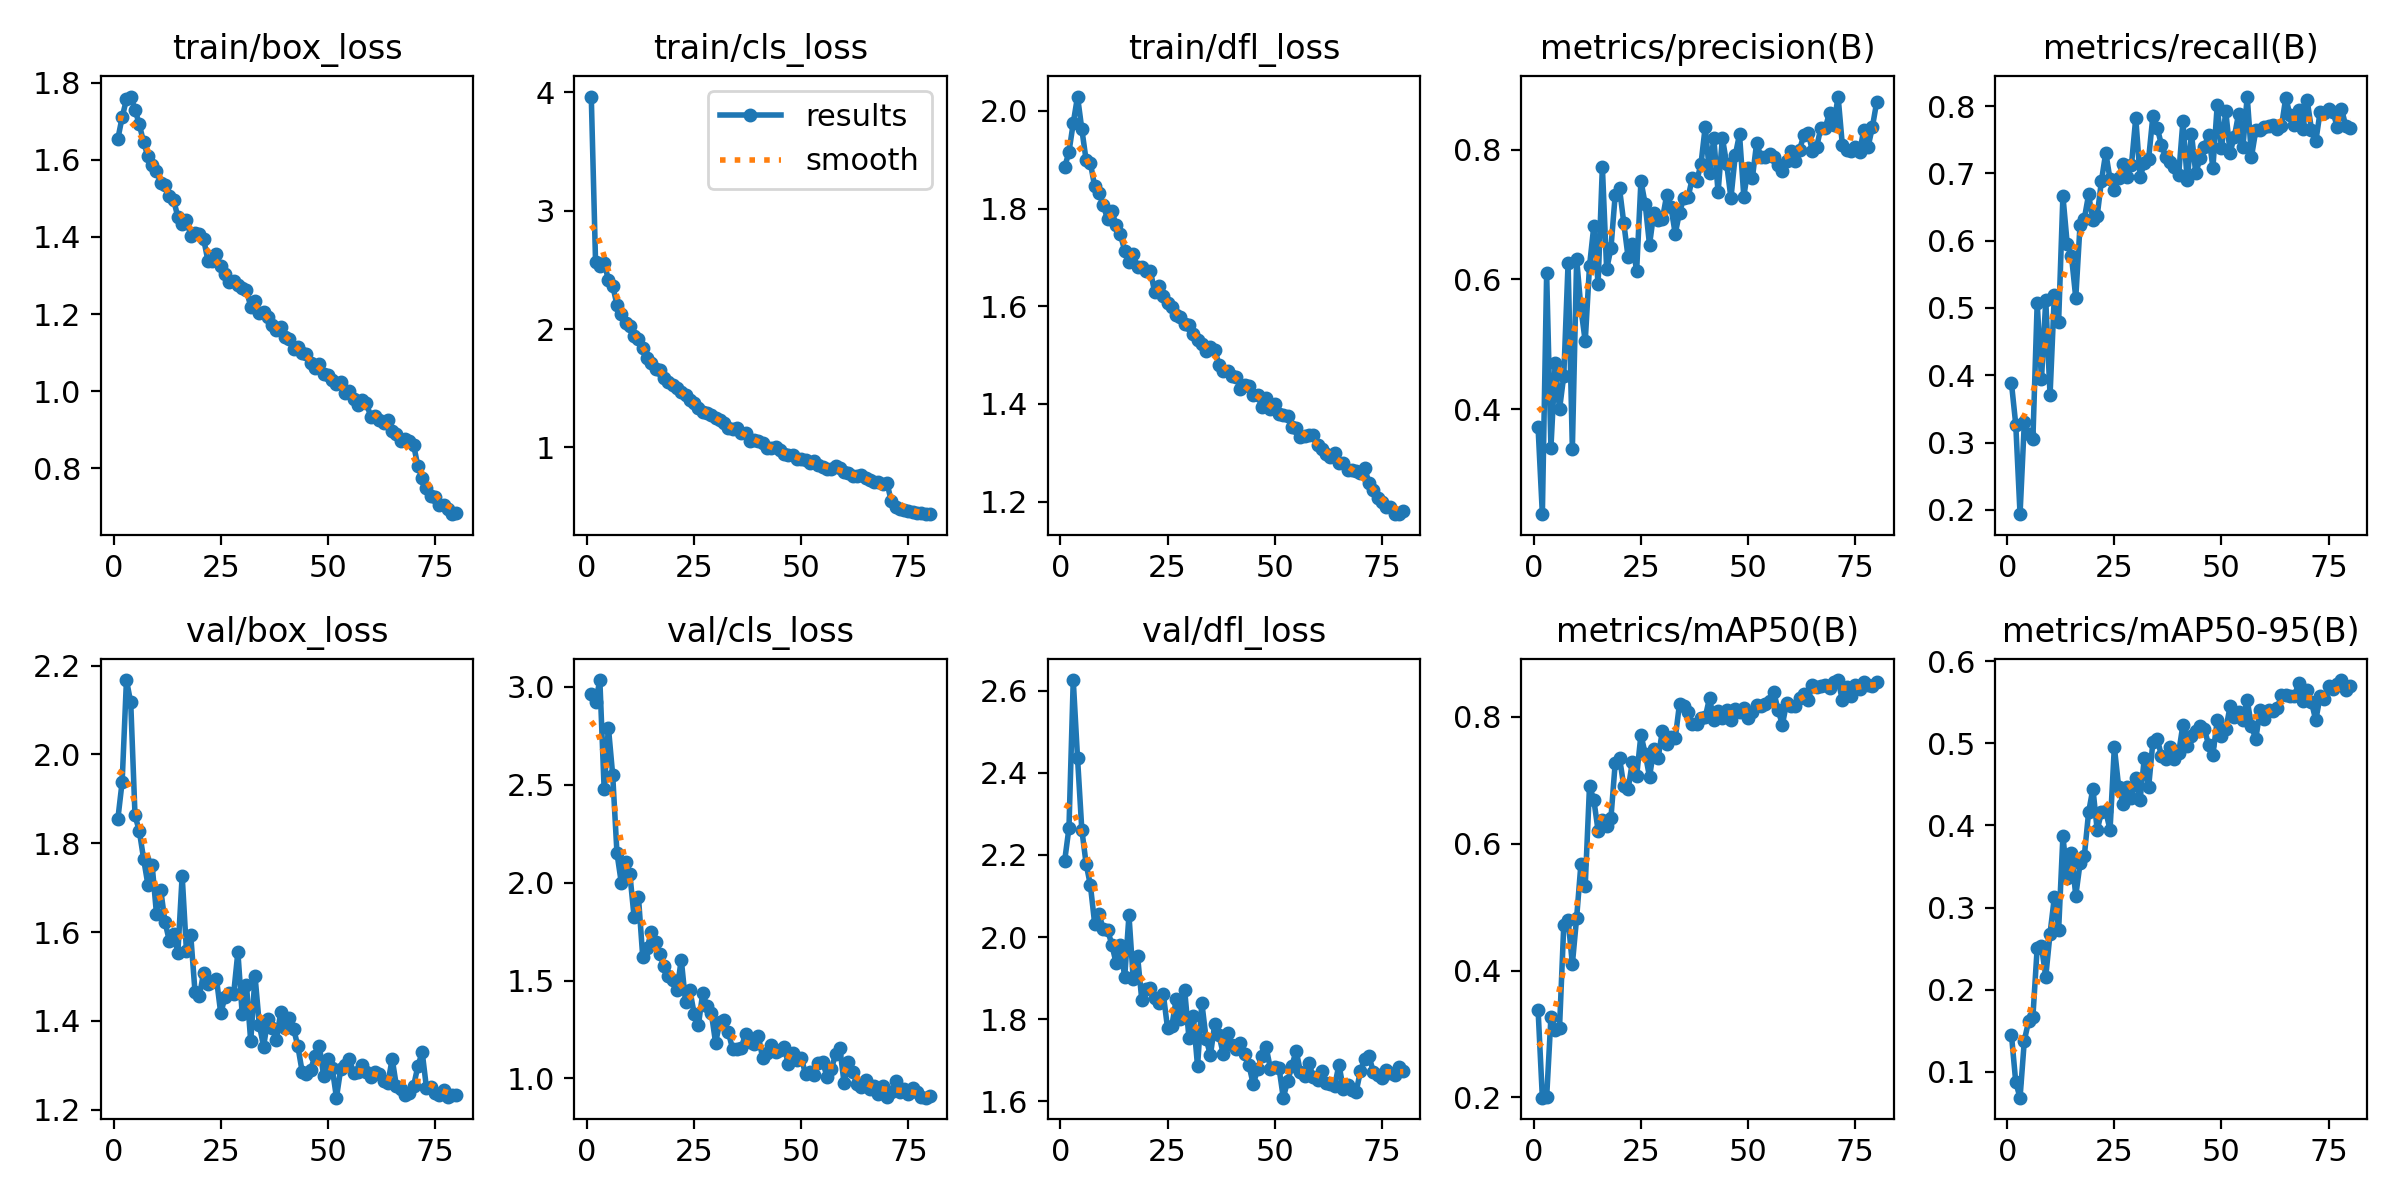

In [14]:
from IPython.display import Image, display

display(Image(filename='runs/detect/train3/results.png'))


In [18]:
from google.colab import files
uploaded = files.upload()


Saving Screenshot 2025-04-25 180929.png to Screenshot 2025-04-25 180929.png


In [21]:
!yolo task=detect mode=predict model=runs/detect/train/weights/best.pt source=/content/Screenshot.png


Ultralytics YOLOv8.2.103 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 168 layers, 11,128,293 parameters, 0 gradients, 28.5 GFLOPs

image 1/1 /content/Screenshot.png: 512x800 3 Sampan-Noukas, 37.8ms
Speed: 4.3ms preprocess, 37.8ms inference, 182.1ms postprocess per image at shape (1, 3, 512, 800)
Results saved to runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


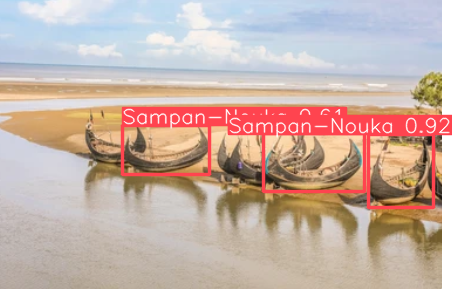

In [24]:
from IPython.display import Image
display(Image(filename='runs/detect/predict/Screenshot.png'))


In [16]:
!yolo task=detect mode=val model=runs/detect/train3/weights/best.pt data=/content/Traditional-boats-of-Bangladesh-15/data.yaml


Ultralytics YOLOv8.2.103 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 168 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs
val: Scanning /content/Traditional-boats-of-Bangladesh-15/valid/labels.cache... 88 images, 0 backgrounds, 0 corrupt: 100% 88/88 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 6/6 [00:03<00:00,  1.96it/s]
                   all         88        160      0.804      0.796      0.851      0.575
           Baich-Nouka         17         29      0.888       0.82      0.893      0.511
           Dingi_Nouka         14         40      0.598      0.575       0.53      0.349
       Fishing trawler          8          8      0.823          1      0.982       0.58
                 Malar         25         46      0.954      0.783      0.926      0.683
           Pansi-Nouka         18         23      0.702      0.719      0.814      0.594
          Sampan-Nouka    

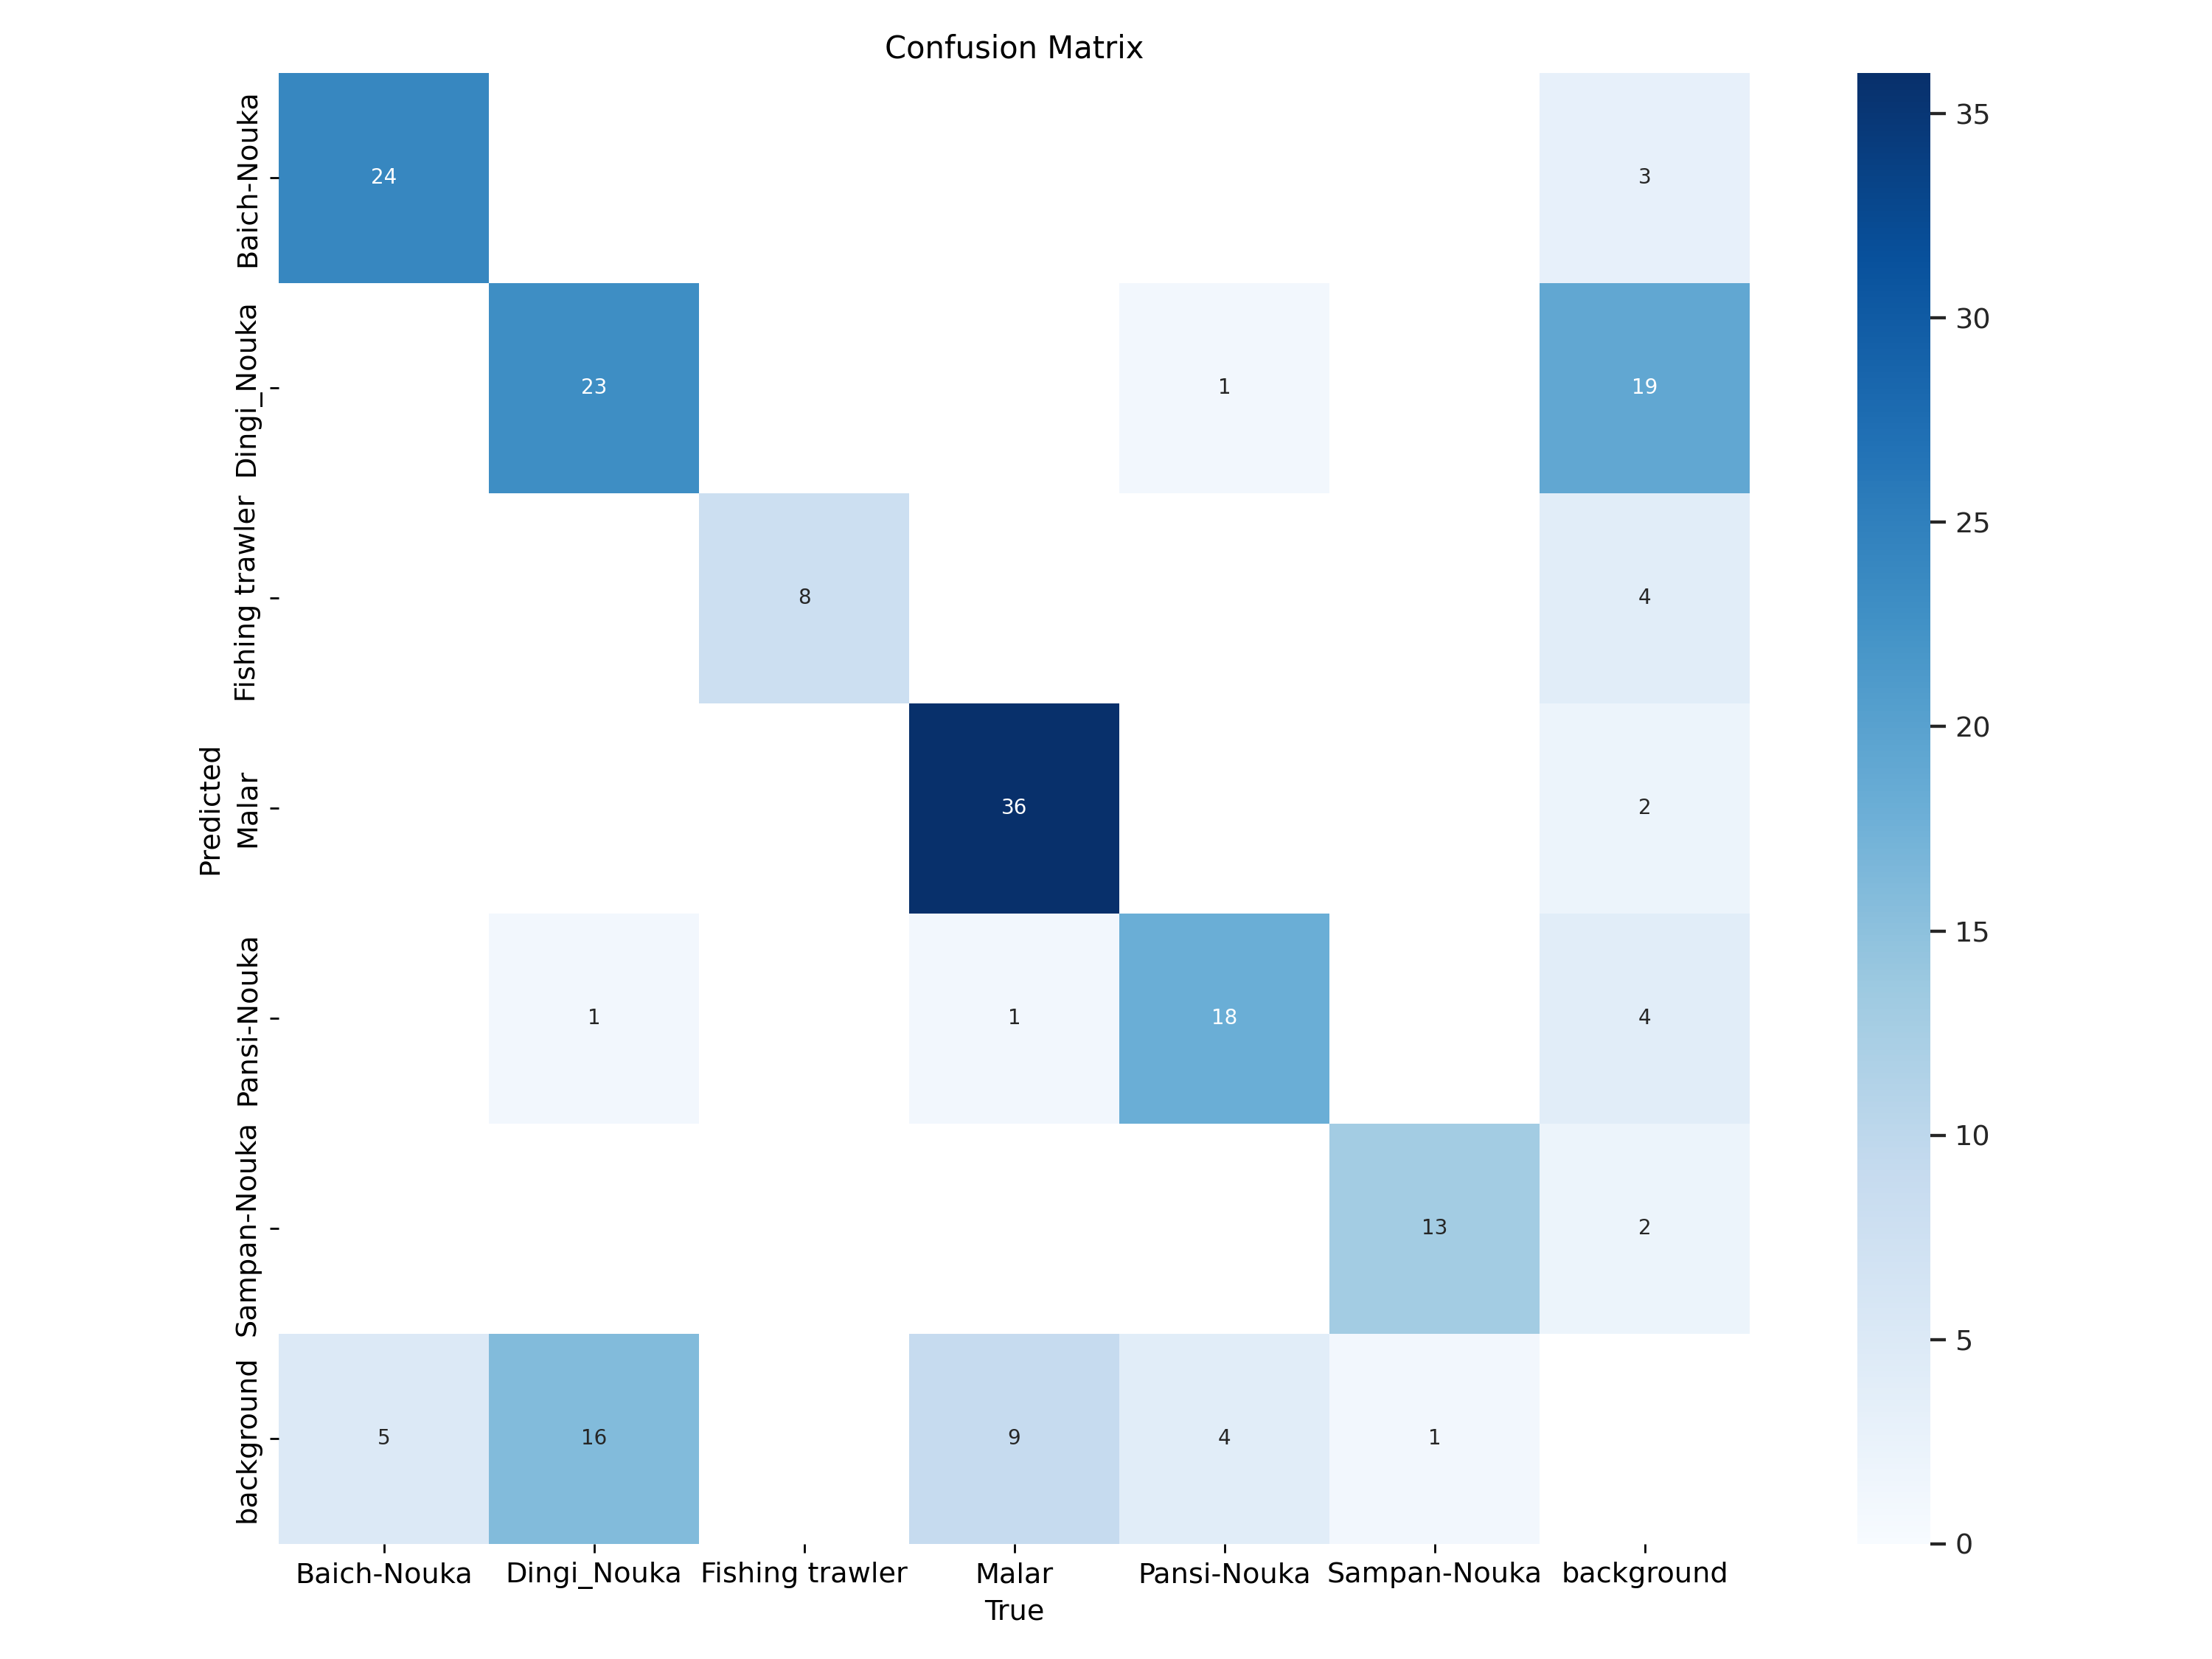

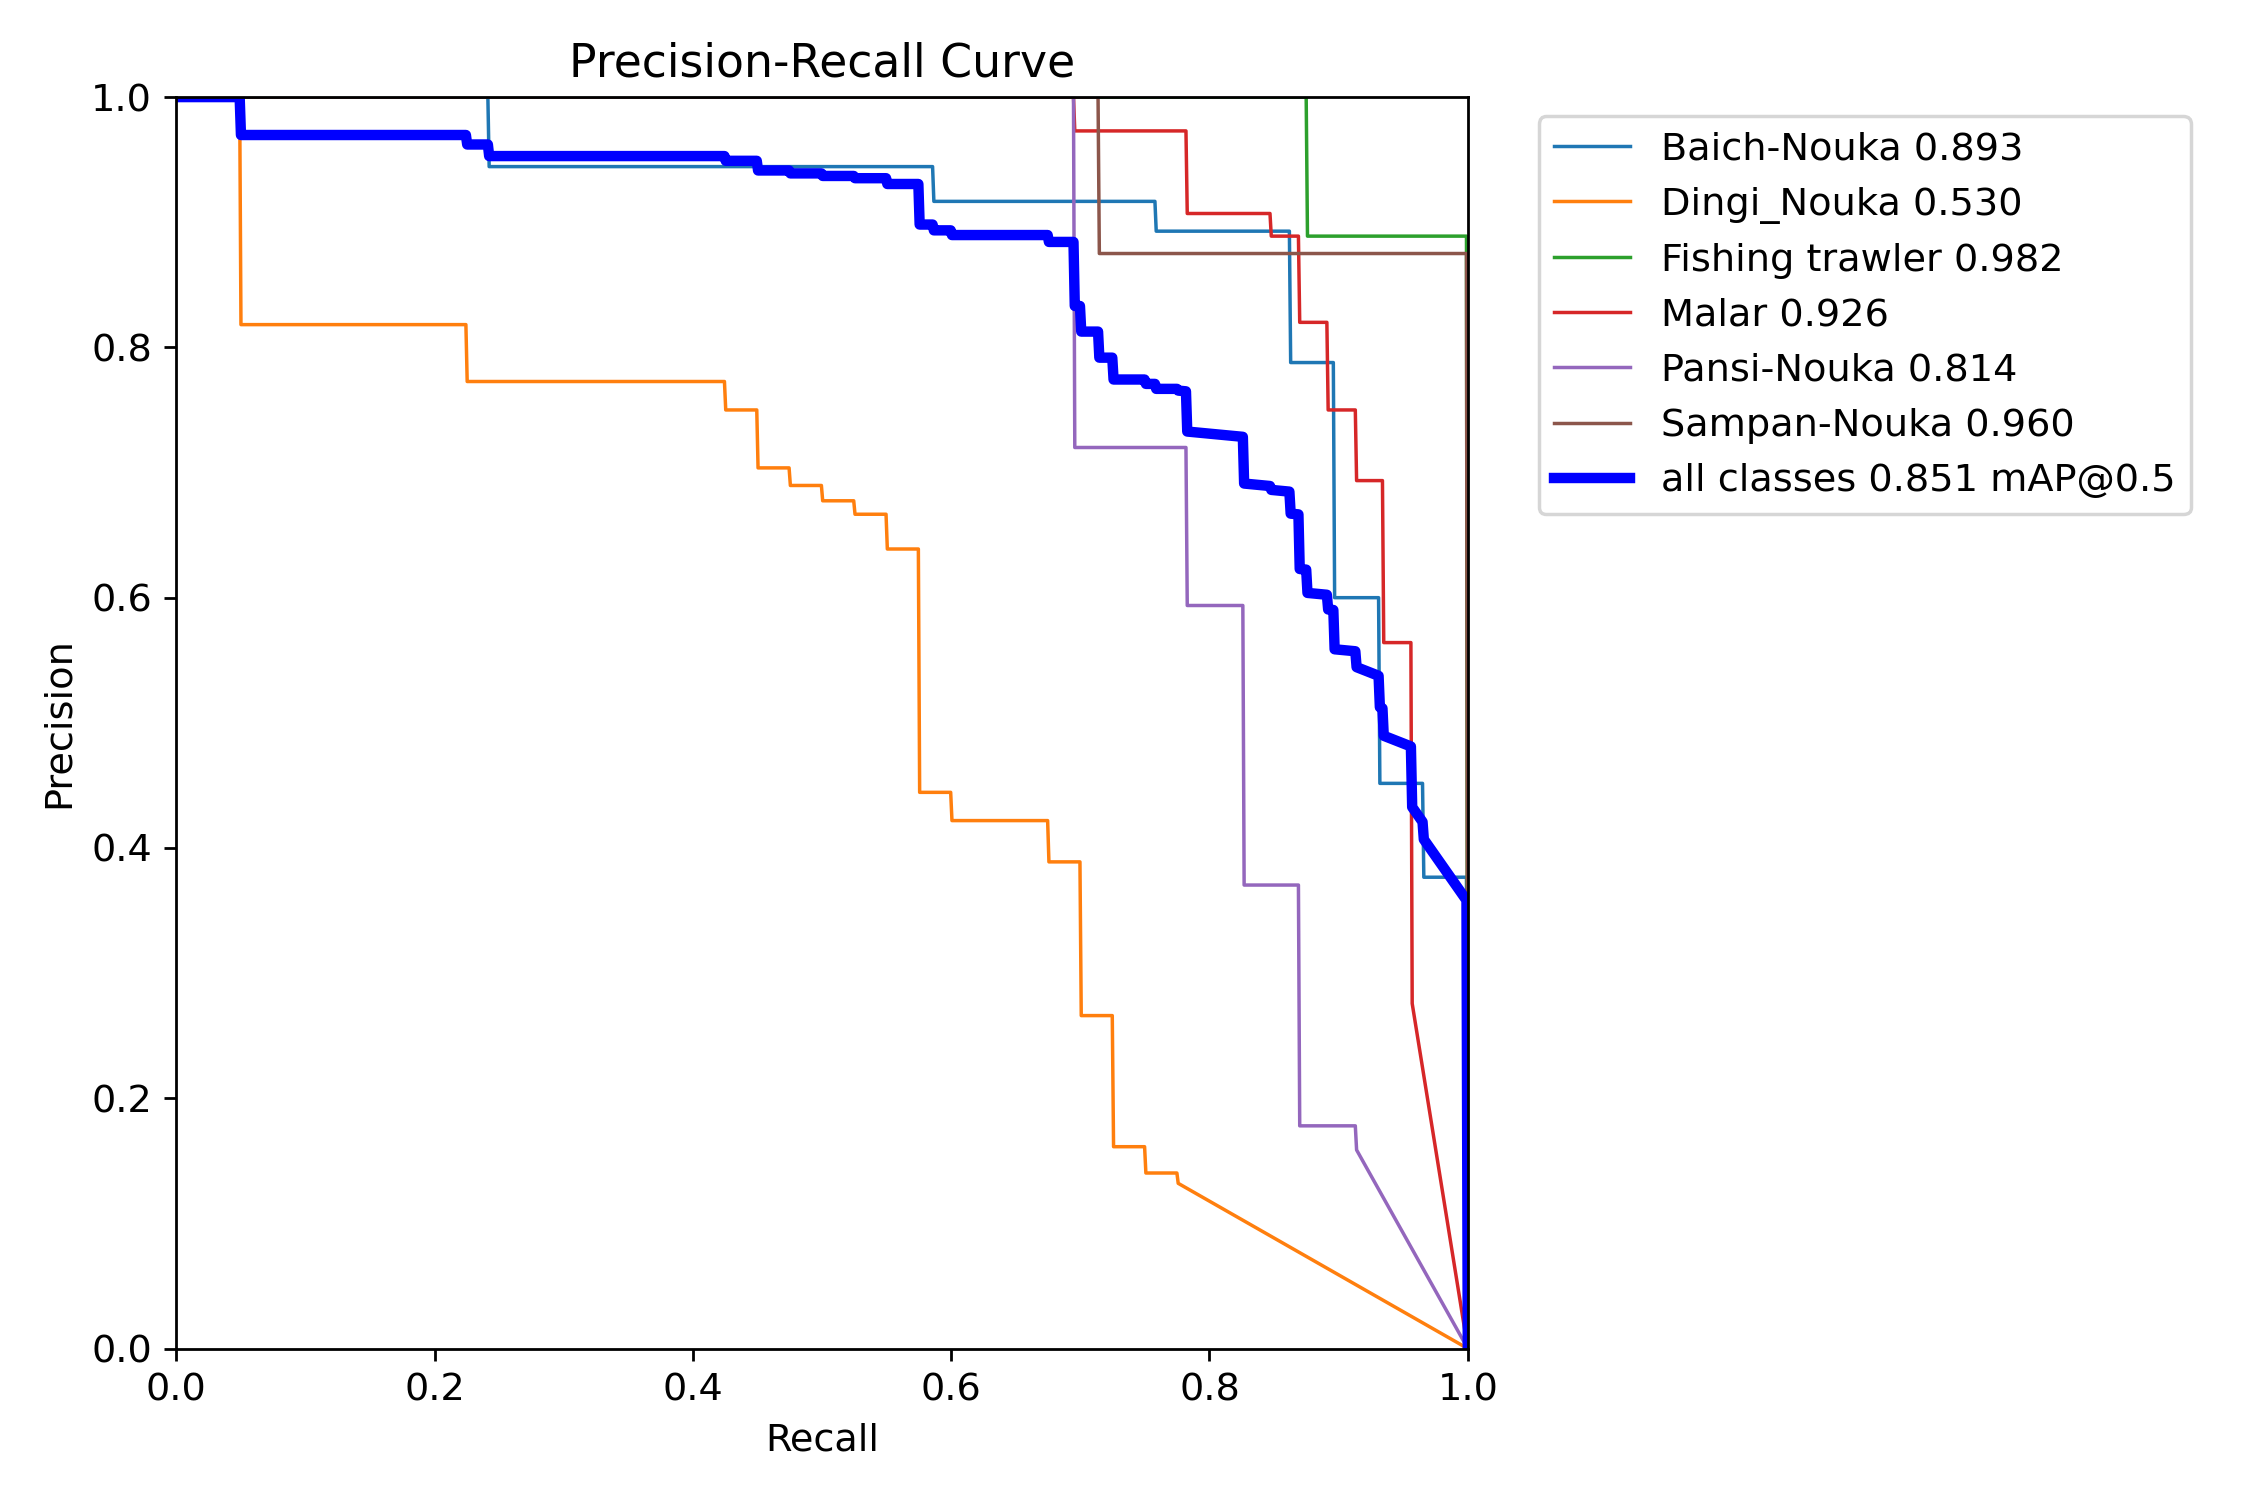

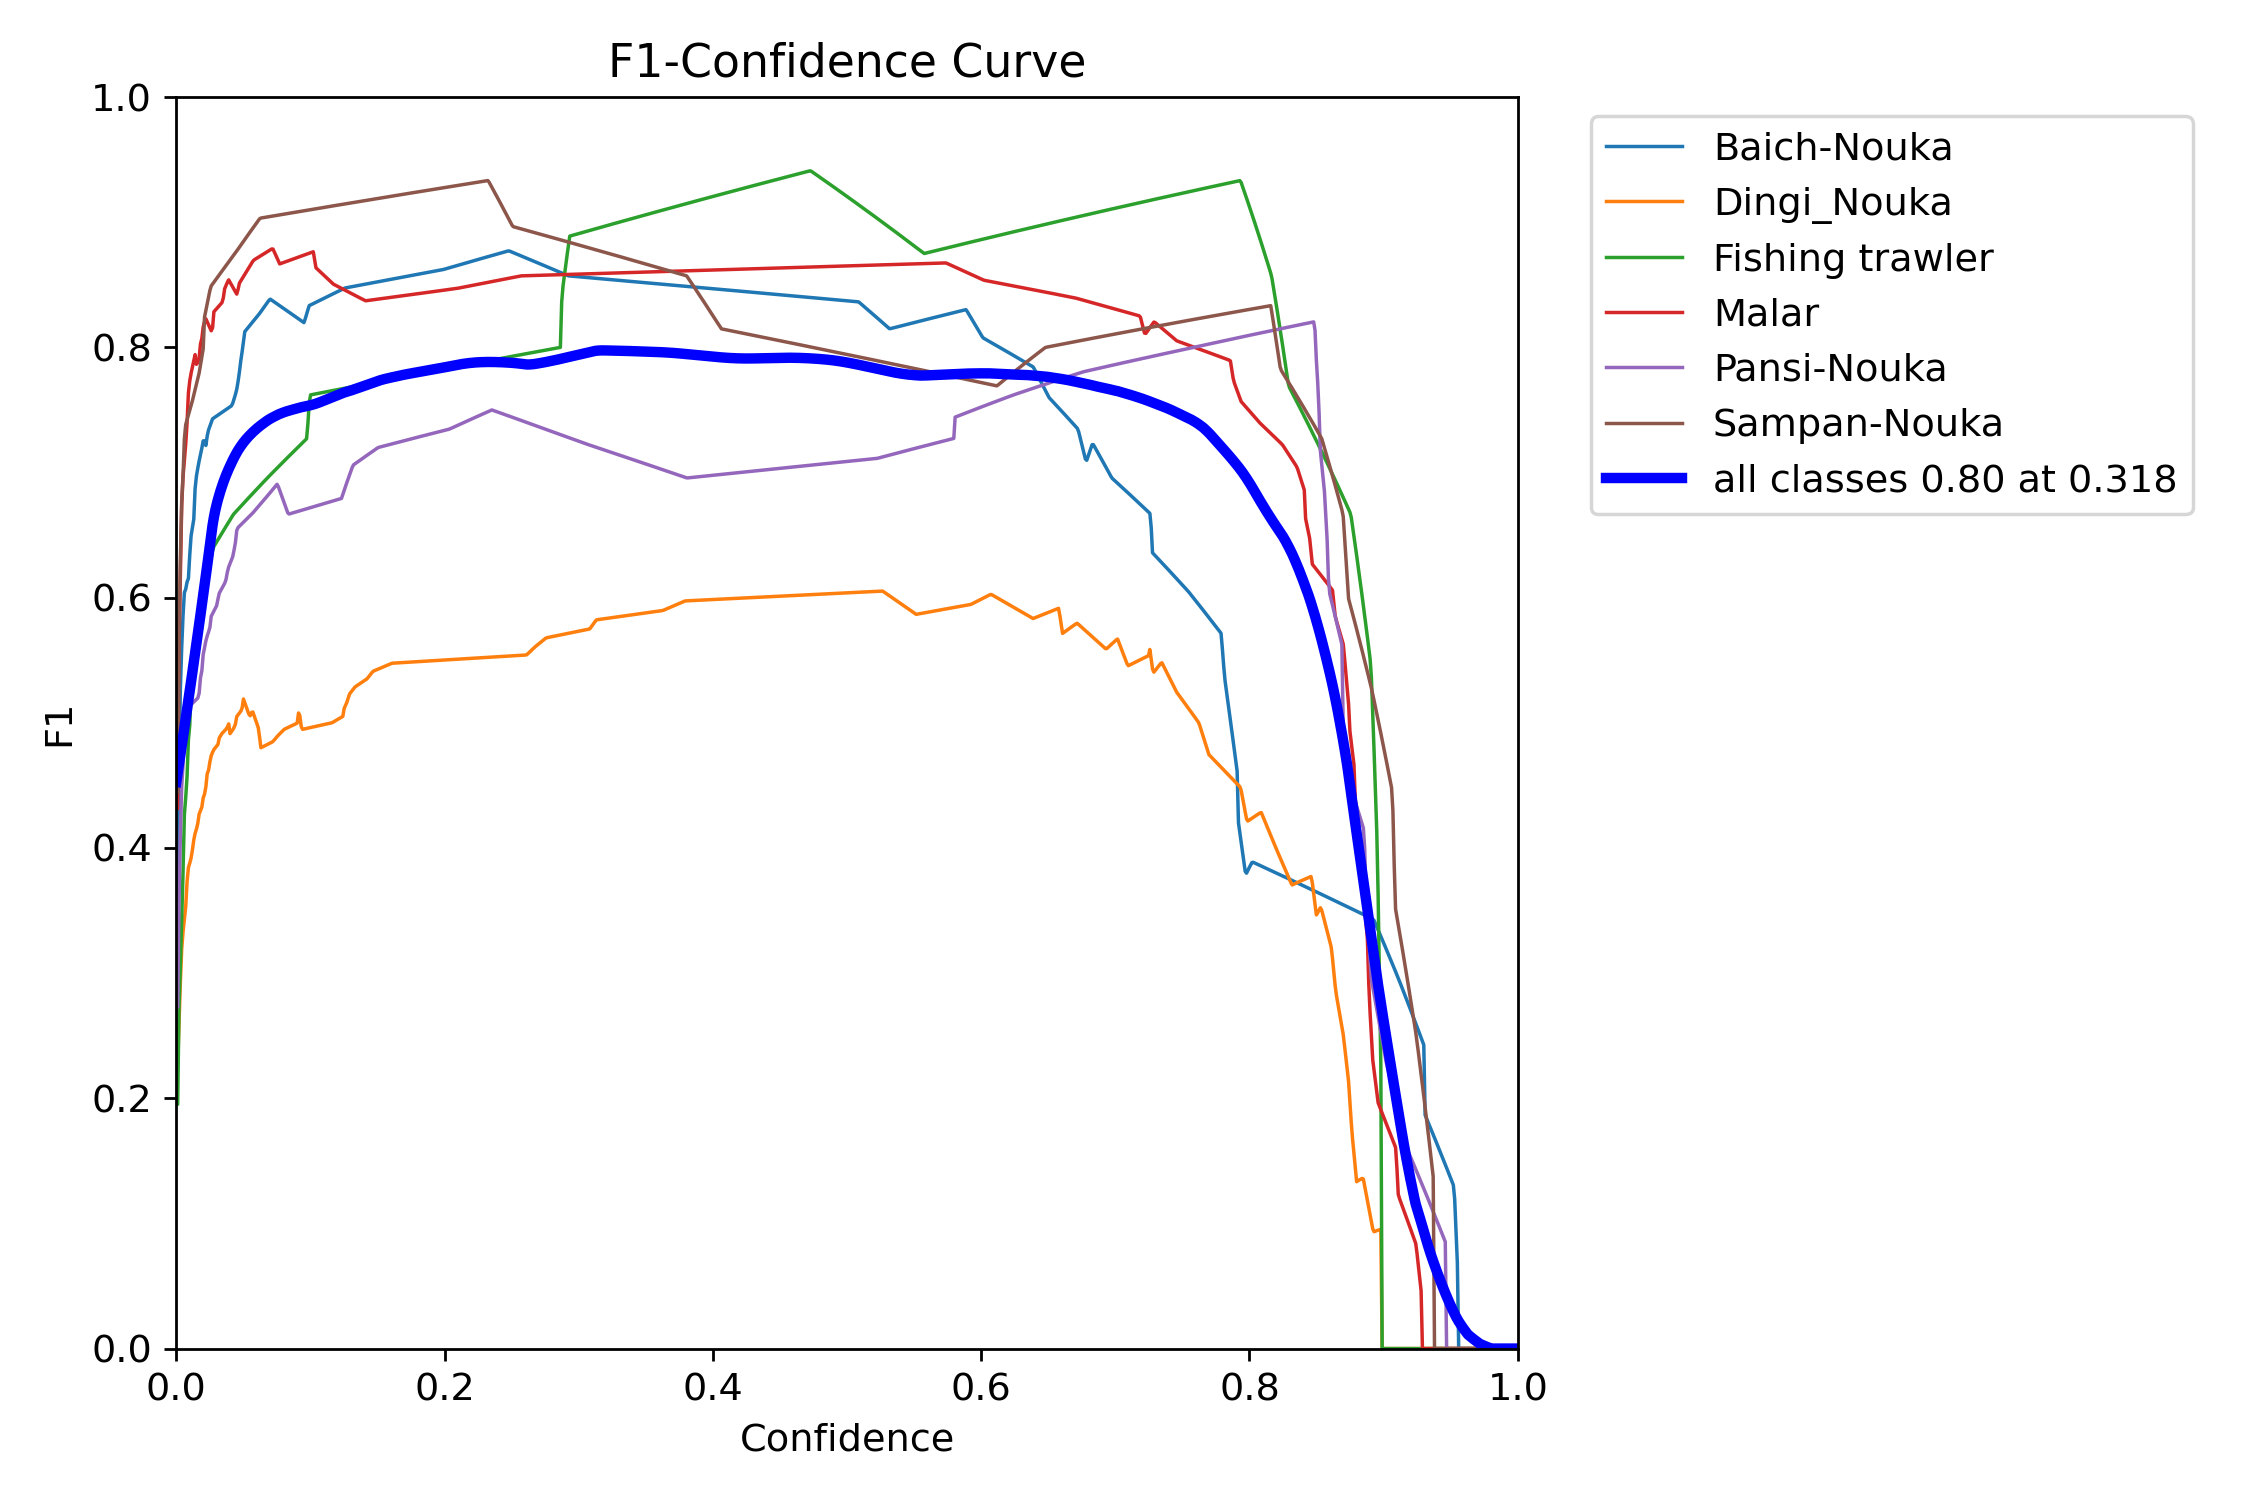

In [17]:
from IPython.display import Image, display

# Change folder name if it's not train3
val_dir = 'runs/detect/val/'

display(Image(filename=val_dir + 'confusion_matrix.png'))
display(Image(filename=val_dir + 'PR_curve.png'))
display(Image(filename=val_dir + 'F1_curve.png'))



In [30]:
!yolo task=detect mode=val model=runs/detect/train3/weights/best.pt data=/content/Traditional-boats-of-Bangladesh-15/data.yaml save_txt=True save_conf=True


Ultralytics YOLOv8.2.103 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 168 layers, 11,128,293 parameters, 0 gradients, 28.5 GFLOPs
val: Scanning /content/Traditional-boats-of-Bangladesh-12/valid/labels.cache... 106 images, 0 backgrounds, 0 corrupt: 100% 106/106 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 7/7 [00:04<00:00,  1.41it/s]
                   all        106        234      0.724      0.716      0.762      0.476
           Baich-Nouka         39         68      0.794      0.926      0.854      0.467
           Dingi_Nouka         13         58      0.447      0.414      0.397      0.244
       Fishing trawler          7         10      0.669        0.8      0.772      0.436
                 Kosha         13         30      0.634      0.567      0.653      0.463
                 Malar         12         14          1      0.561      0.905      0.611
           Pansi-Nouka 

In [18]:
!yolo task=detect mode=predict model=runs/detect/train3/weights/best.pt source=/content/test_images save=True



Ultralytics YOLOv8.2.103 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 168 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs

image 1/31 /content/test_images/-across-river-sadarghat-dhaka-bangladesh-transporting-local-people-164239386_jpg.rf.bba6b190825d3cb5f6cfdafb089026e2.jpg: 800x800 1 Pansi-Nouka, 25.5ms
image 2/31 /content/test_images/1000_F_140189966_3S8CdjYH2f91pNFXhj4aT1oxJ1VBsp8l_jpg.rf.bbe512d9095cf7bf26f31ec2fc5dd3ec.jpg: 800x800 (no detections), 23.0ms
image 3/31 /content/test_images/1561648776_jpg.rf.19794e5ca79e4d174d1cc6634d98382f.jpg: 800x800 6 Dingi_Noukas, 22.9ms
image 4/31 /content/test_images/17378955135_b4b97d1038_b_jpg.rf.3cb2e8a5bbac6b6aeadfea3d036cb2d2.jpg: 800x800 1 Dingi_Nouka, 1 Pansi-Nouka, 22.9ms
image 5/31 /content/test_images/34f2b33ca8e61cdee5a1688e16156e69_jpg.rf.a947e7f6136706c203ade6829d1cd10d.jpg: 800x800 1 Pansi-Nouka, 23.3ms
image 6/31 /content/test_images/63238040_jpg.rf.58a5d743b496ad180eb8a261587d1b9

In [20]:
import os
from IPython.display import Image, display

result_folder = 'runs/detect/predict'

# Display all result images
for filename in os.listdir(result_folder):
    if filename.endswith(('.jpg', '.png')):
        display(Image(filename=os.path.join(result_folder, filename)))


Output hidden; open in https://colab.research.google.com to view.

In [21]:
!zip -r train3.zip runs/detect/train3


  adding: runs/detect/train3/ (stored 0%)
  adding: runs/detect/train3/labels_correlogram.jpg (deflated 39%)
  adding: runs/detect/train3/val_batch2_labels.jpg (deflated 5%)
  adding: runs/detect/train3/val_batch2_pred.jpg (deflated 5%)
  adding: runs/detect/train3/train_batch2.jpg (deflated 1%)
  adding: runs/detect/train3/train_batch8190.jpg (deflated 6%)
  adding: runs/detect/train3/val_batch0_pred.jpg (deflated 5%)
  adding: runs/detect/train3/confusion_matrix_normalized.png (deflated 21%)
  adding: runs/detect/train3/val_batch1_labels.jpg (deflated 5%)
  adding: runs/detect/train3/train_batch1.jpg (deflated 1%)
  adding: runs/detect/train3/R_curve.png (deflated 9%)
  adding: runs/detect/train3/labels.jpg (deflated 16%)
  adding: runs/detect/train3/train_batch0.jpg (deflated 1%)
  adding: runs/detect/train3/results.png (deflated 7%)
  adding: runs/detect/train3/weights/ (stored 0%)
  adding: runs/detect/train3/weights/last.pt (deflated 8%)
  adding: runs/detect/train3/weights/best.

In [22]:
from google.colab import files
files.download("train3.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>